# 0. Импорты и конфигурация

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from linear_torch import TorchMLP, ClassificationLoss
from linear_custom import CustomMLP
from sklearn.metrics import accuracy_score, f1_score

Укажите на чем будете обучать модели

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Для воспроизводимости экспериментов:

In [3]:
torch.manual_seed(239)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(239)

# 1. Данные

В функции `get_dataloaders` реализованы скачивание датасета MNIST, приведение типа данных к торч-тензорам (`transforms.ToTensor()`), нормализация данных (`transforms.Normalize(...)`) и создание даталоадеров (специальных объектов, которые выдают батч данных на каждой итерации обучения модели).

In [4]:
def get_dataloaders(batch_size: int = 128, data_dir: str = './data'):
    """Создаёт DataLoader'ы для MNIST (train и test)."""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),  # стандартное нормирование MNIST
    ])

    train_dataset = datasets.MNIST(
        root=data_dir,
        train=True,
        download=True,
        transform=transform,
    )
    test_dataset = datasets.MNIST(
        root=data_dir,
        train=False,
        download=True,
        transform=transform,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )
    return train_loader, test_loader


Ваша задача - `train_loader` и `test_loader` даталоадеры с помощью этой функции, а также вывести количество объектов в train и test выборках. 

In [5]:
train_loader, test_loader = get_dataloaders()
print(f"Train samples: {len(train_loader.dataset)}")
print(f"Test samples: {len(test_loader.dataset)}")

Train samples: 60000
Test samples: 10000


# 2. Обучение нейронных сетей

Напишите функцию `train_epoch`, задача которой - обучение модели на одной эпохе.

Эта функция должна принимать на вход:
- саму модель, которую вы обучаете
- даталоадер, на котором обучаете
- оптимизатор (например, AdamW или SGD, на ваш выбор)
- функцию потерь
- девайс (аргумент по умолчанию - `'cpu'`)

Можете добавить свои аргументы по желанию, но все они должны быть аргументами по умолчанию.

ВАЖНО: эта функция должна быть независима от того, обучаете ли вы модель из `linear_torch.py` или `linear_custom.py`.

Совет: выводите среднее значение функции потерь на эпоху для дальнейшей оценки качества обучения модели

In [6]:
def train_epoch(
        model: torch.nn.Module,
        dataloader: DataLoader,
        optimizer: torch.optim.Optimizer,
        criterion: torch.nn.Module,
        device: str = 'cpu'
):
    model.train()
    total_loss = 0
    num_batches = 0
    for data, target in dataloader:
        data, target = data.to(device), target.to(device)
        data = data.view(data.size(0), -1)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        num_batches += 1
        
    avg_loss = total_loss / num_batches
    print(f"Train Epoch Loss: {avg_loss:.4f}")
    return avg_loss

Далее напишите функцию `evaluate`, которая должна заниматься оценкой обучения модели. Эта модель также принимает на вход:
- саму модель, которую вы оцениваете
- даталоадер, на котором оцениваете
- функцию потерь, она должна совпадать с той функцией потерь, на которой обучаете (почему?)
- девайс, на котором обучаете (аргумент по умолчанию - `'cpu'`)

Можете добавить свои аргументы по желанию, но все они должны быть аргументами по умолчанию.

Эта модель должна выводить среднее значение функции потерь и словарь, ключи которого - названия метрик классификации, а значения - числовые значения этих метрик (обязательные к выводу метрики - accuracy и f1-score)

ВАЖНО: эта функция должна быть независима от того, оцениваете ли вы модель из `linear_torch.py` или `linear_custom.py`.

In [7]:
def evaluate(
        model: torch.nn.Module,
        dataloader: DataLoader,
        criterion: torch.nn.Module,
        device: str = 'cpu'
):
    model.eval()
    total_loss = 0
    num_batches = 0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            data = data.view(data.size(0), -1)
            output = model(data)
            loss = criterion(output, target)
            total_loss += loss.item()
            num_batches += 1
            preds = torch.argmax(output, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    avg_loss = total_loss / num_batches
    accuracy = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro')
    metrics = {'accuracy': accuracy, 'f1-score': f1}
    print(f"Eval Loss: {avg_loss:.4f}, Metrics: {metrics}")
    
    return avg_loss, metrics

Теперь создайте объекты моделей из `linear_torch.py` или `linear_custom.py`.

Создайте эти модели с одинаковым количеством параметров

In [8]:
torch_model = TorchMLP(input_dim=784, hidden_dim=128, output_dim=10).to(device)
custom_model = CustomMLP(input_dim=784, hidden_dim=128, output_dim=10).to(device)

Выберите гиперпараметры обучения, запишите их в переменные

In [9]:
lr = 0.001
epochs = 15

## 2.1 Обучение torch-версии модели

Создайте объекты оптимизатора и функции потерь для torch-версии.

In [10]:
torch_optimizer = torch.optim.Adam(torch_model.parameters(), lr=lr)
torch_criterion = ClassificationLoss()

Обучите модель, не забывайте в конце каждой эпохи оценивать качество модели

In [11]:
torch_train_losses = []
torch_val_losses = []
torch_metrics_history = []

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    train_loss = train_epoch(torch_model, train_loader, torch_optimizer, torch_criterion, device)
    val_loss, metrics = evaluate(torch_model, test_loader, torch_criterion, device)
    torch_train_losses.append(train_loss)
    torch_val_losses.append(val_loss)
    torch_metrics_history.append(metrics)

Epoch 1/15
Train Epoch Loss: 0.4363
Eval Loss: 0.1989, Metrics: {'accuracy': 0.9402, 'f1-score': 0.9395644786198408}
Epoch 2/15
Train Epoch Loss: 0.2567
Eval Loss: 0.1521, Metrics: {'accuracy': 0.9544, 'f1-score': 0.9539138028335724}
Epoch 3/15
Train Epoch Loss: 0.2171
Eval Loss: 0.1305, Metrics: {'accuracy': 0.9608, 'f1-score': 0.9604617771070613}
Epoch 4/15
Train Epoch Loss: 0.1960
Eval Loss: 0.1199, Metrics: {'accuracy': 0.9639, 'f1-score': 0.9635512810790272}
Epoch 5/15
Train Epoch Loss: 0.1795
Eval Loss: 0.1112, Metrics: {'accuracy': 0.9676, 'f1-score': 0.9673721769963736}
Epoch 6/15
Train Epoch Loss: 0.1676
Eval Loss: 0.1013, Metrics: {'accuracy': 0.9698, 'f1-score': 0.9695176982079747}
Epoch 7/15
Train Epoch Loss: 0.1583
Eval Loss: 0.0949, Metrics: {'accuracy': 0.9708, 'f1-score': 0.970544900751185}
Epoch 8/15
Train Epoch Loss: 0.1512
Eval Loss: 0.0955, Metrics: {'accuracy': 0.9706, 'f1-score': 0.9703831376315876}
Epoch 9/15
Train Epoch Loss: 0.1407
Eval Loss: 0.0897, Metrics: {

Постройте графики:
- совмещенный график функции потерь на тренировочном и валидационном наборах данных
- совмещенный график каждой из метрик

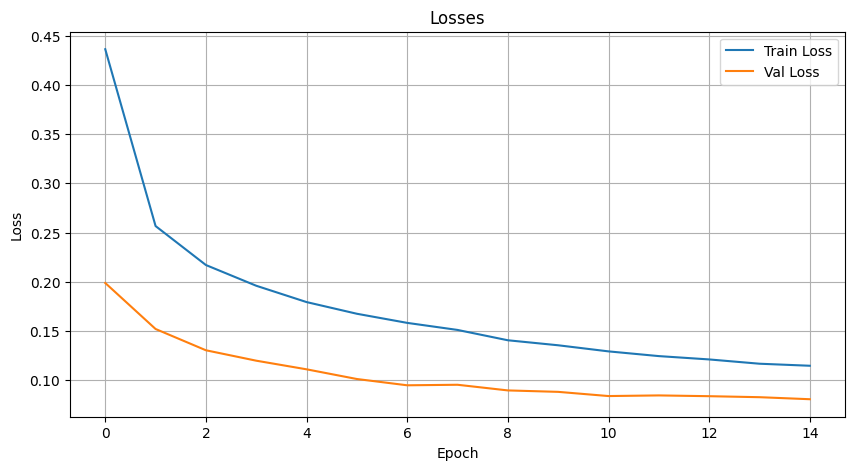

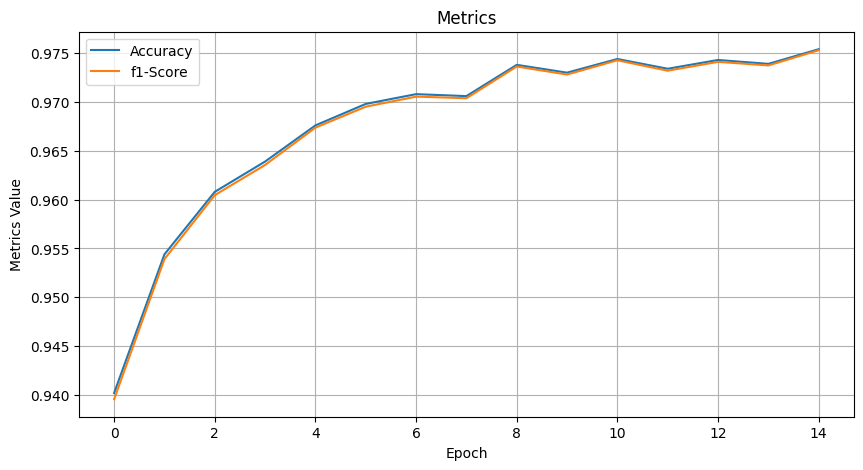

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(torch_train_losses, label='Train Loss')
plt.plot(torch_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Losses')
plt.grid(True)
plt.legend()
plt.show()

acc = [m['accuracy'] for m in torch_metrics_history]
f1 = [m['f1-score'] for m in torch_metrics_history]

plt.figure(figsize=(10, 5))
plt.plot(acc, label='Accuracy')
plt.plot(f1, label='f1-Score')
plt.xlabel('Epoch')
plt.ylabel('Metrics Value')
plt.title('Metrics')
plt.grid(True)
plt.legend()
plt.show()

## 2.2 Обучение custom-версии модели

Создайте объекты оптимизатора и функции потерь для custom-версии

In [13]:
custom_optimizer = torch.optim.Adam(custom_model.parameters(), lr=lr)
custom_criterion = ClassificationLoss()

Обучите модель

In [14]:
custom_train_losses = []
custom_val_losses = []
custom_metrics_history = []

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    train_loss = train_epoch(custom_model, train_loader, custom_optimizer, custom_criterion, device)
    val_loss, metrics = evaluate(custom_model, test_loader, custom_criterion, device)
    custom_train_losses.append(train_loss)
    custom_val_losses.append(val_loss)
    custom_metrics_history.append(metrics)

Epoch 1/15
Train Epoch Loss: 0.4342
Eval Loss: 0.1883, Metrics: {'accuracy': 0.9446, 'f1-score': 0.9440167880376364}
Epoch 2/15
Train Epoch Loss: 0.2544
Eval Loss: 0.1488, Metrics: {'accuracy': 0.9574, 'f1-score': 0.956982988321997}
Epoch 3/15
Train Epoch Loss: 0.2172
Eval Loss: 0.1300, Metrics: {'accuracy': 0.962, 'f1-score': 0.9616149315438755}
Epoch 4/15
Train Epoch Loss: 0.1936
Eval Loss: 0.1189, Metrics: {'accuracy': 0.9652, 'f1-score': 0.9648791468243065}
Epoch 5/15
Train Epoch Loss: 0.1790
Eval Loss: 0.1080, Metrics: {'accuracy': 0.9683, 'f1-score': 0.9681370006133418}
Epoch 6/15
Train Epoch Loss: 0.1666
Eval Loss: 0.1031, Metrics: {'accuracy': 0.9699, 'f1-score': 0.969685580549849}
Epoch 7/15
Train Epoch Loss: 0.1548
Eval Loss: 0.0995, Metrics: {'accuracy': 0.9694, 'f1-score': 0.9691849670079344}
Epoch 8/15
Train Epoch Loss: 0.1469
Eval Loss: 0.0921, Metrics: {'accuracy': 0.9734, 'f1-score': 0.9732414517598821}
Epoch 9/15
Train Epoch Loss: 0.1402
Eval Loss: 0.0900, Metrics: {'a

Постройте графики:
- совмещенный график функции потерь на тренировочном и валидационном наборах данных
- совмещенный график каждой из метрик

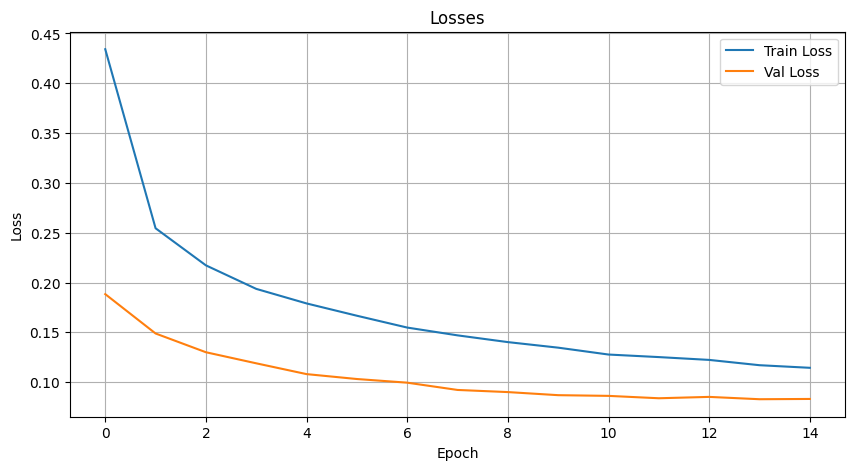

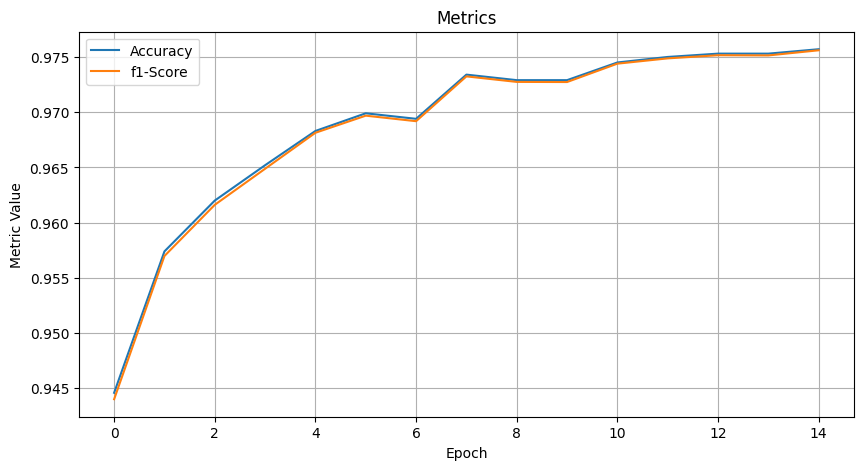

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(custom_train_losses, label='Train Loss')
plt.plot(custom_val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Losses')
plt.grid(True)
plt.legend()
plt.show()

acc = [m['accuracy'] for m in custom_metrics_history]
f1 = [m['f1-score'] for m in custom_metrics_history]

plt.figure(figsize=(10, 5))
plt.plot(acc, label='Accuracy')
plt.plot(f1, label='f1-Score')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('Metrics')
plt.grid(True)
plt.legend()
plt.show()